In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from imblearn.over_sampling import SMOTE 
import optuna
from sklearn.metrics import accuracy_score, r2_score

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42

class_cv = StratifiedKFold(5, shuffle = True, random_state = RANDOM_STATE)
reg_cv = KFold(5, shuffle = True, random_state = RANDOM_STATE)

**Загрузка датасетов**

In [58]:
class_df = pd.read_csv("../csv/cl_finished.csv", sep = ";")
X_class = class_df.drop(columns = "Diabetes_012")
y_class = class_df["Diabetes_012"]

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class, test_size = 0.3, stratify = y_class)

In [59]:
regress_df = pd.read_csv("../csv/winequality_finished.csv", sep = ";")
X_reg = regress_df.drop(columns = "quality")
y_reg = regress_df["quality"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size = 0.3)

**Модели решающих деревьев**

In [70]:

def objective_trees(trial, model_type):
    if model_type == "classification":
        max_depth = trial.suggest_int("max_depth", 2, 64, log = True)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 32)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 32)

        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        model = DecisionTreeClassifier(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)
        
        score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()
        
        return score

    
    if model_type == "regression":

        max_depth = trial.suggest_int("max_depth", 2, 64, log = True)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 16)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 16)

        criterion = trial.suggest_categorical("criterion", ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'])

        model = DecisionTreeRegressor(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)

        score = cross_val_score(model, X_reg_train, y_reg_train, cv = reg_cv, scoring = "neg_mean_squared_error").mean()

        return score

In [61]:
study_class = optuna.create_study(direction = "maximize")
study_class.optimize(lambda trial: objective_trees(trial, "classification"), n_trials = 25)

best_class_tree_model = DecisionTreeClassifier(**study_class.best_params, random_state = RANDOM_STATE)
best_class_tree_model.fit(X_class_train, y_class_train)

[I 2026-05-22 12:23:10,956] A new study created in memory with name: no-name-6f825638-dd3f-49ca-8367-82f67cb14889
[I 2026-05-22 12:23:14,170] Trial 0 finished with value: 0.8170113112892199 and parameters: {'max_depth': 43, 'min_samples_split': 3, 'min_samples_leaf': 11, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8170113112892199.
[I 2026-05-22 12:23:14,979] Trial 1 finished with value: 0.827487164002615 and parameters: {'max_depth': 3, 'min_samples_split': 24, 'min_samples_leaf': 8, 'criterion': 'gini'}. Best is trial 1 with value: 0.827487164002615.
[I 2026-05-22 12:23:15,593] Trial 2 finished with value: 0.8271141340669628 and parameters: {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 1 with value: 0.827487164002615.
[I 2026-05-22 12:23:18,166] Trial 3 finished with value: 0.8271327911682775 and parameters: {'max_depth': 45, 'min_samples_split': 31, 'min_samples_leaf': 27, 'criterion': 'entropy'}. Best is trial 1 with 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'log_loss'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",25
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",29
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [62]:
pred = best_class_tree_model.predict(X_class_test)
print(accuracy_score(pred, y_class_test))

0.8333067382316676


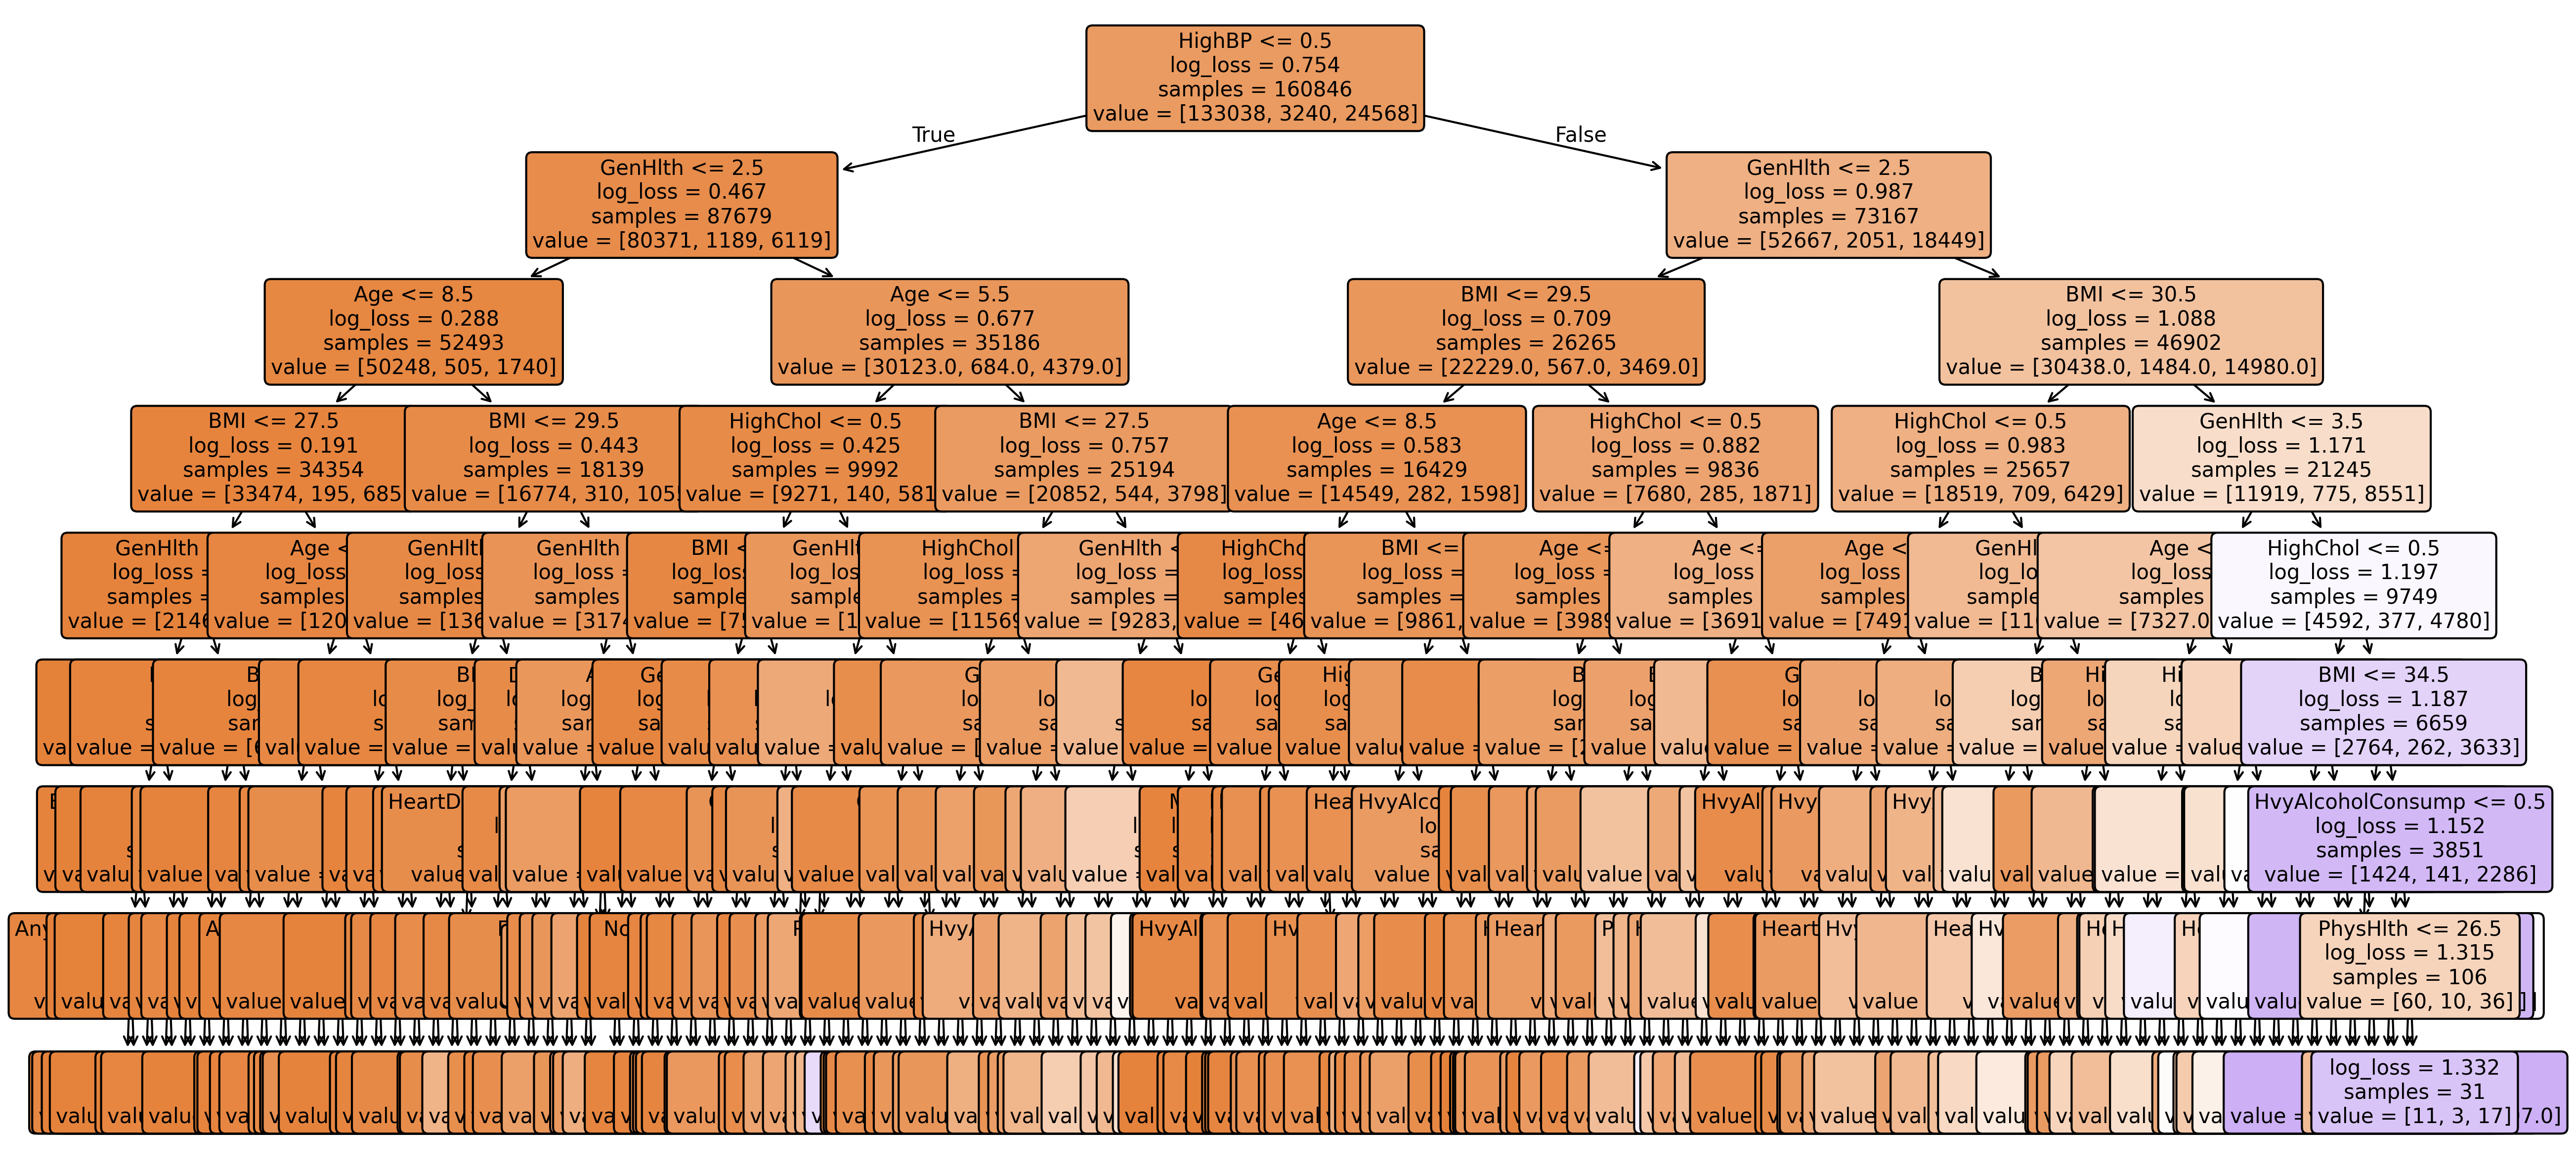

In [ ]:
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    best_class_tree_model,
    max_depth=8,
    feature_names=X_class.columns,
    filled=True,
    rounded=True,
    fontsize=10,
)

plt.show()

In [71]:
study_reg = optuna.create_study(direction = "maximize")
study_reg.optimize(lambda trial: objective_trees(trial, "regression"), n_trials = 25)

best_reg_tree_model = DecisionTreeRegressor(**study_reg.best_params, random_state = RANDOM_STATE)
best_reg_tree_model.fit(X_reg_train, y_reg_train)

[I 2026-05-22 12:35:39,420] A new study created in memory with name: no-name-50182443-907a-443c-98f7-d7ef591fefc9
[I 2026-05-22 12:35:39,588] Trial 0 finished with value: -0.5576330632794837 and parameters: {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 6, 'criterion': 'squared_error'}. Best is trial 0 with value: -0.5576330632794837.
[I 2026-05-22 12:35:39,634] Trial 1 finished with value: -0.5943018150611924 and parameters: {'max_depth': 2, 'min_samples_split': 4, 'min_samples_leaf': 6, 'criterion': 'poisson'}. Best is trial 0 with value: -0.5576330632794837.
[I 2026-05-22 12:35:39,945] Trial 2 finished with value: -0.660928746720826 and parameters: {'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 2, 'criterion': 'absolute_error'}. Best is trial 0 with value: -0.5576330632794837.
[I 2026-05-22 12:35:40,024] Trial 3 finished with value: -0.5576330632794837 and parameters: {'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 6, 'criterion': 'squared_er

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",13
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [74]:
pred_reg = best_reg_tree_model.predict(X_reg_test)
print(r2_score(y_reg_test, pred_reg))

0.3038306252297486


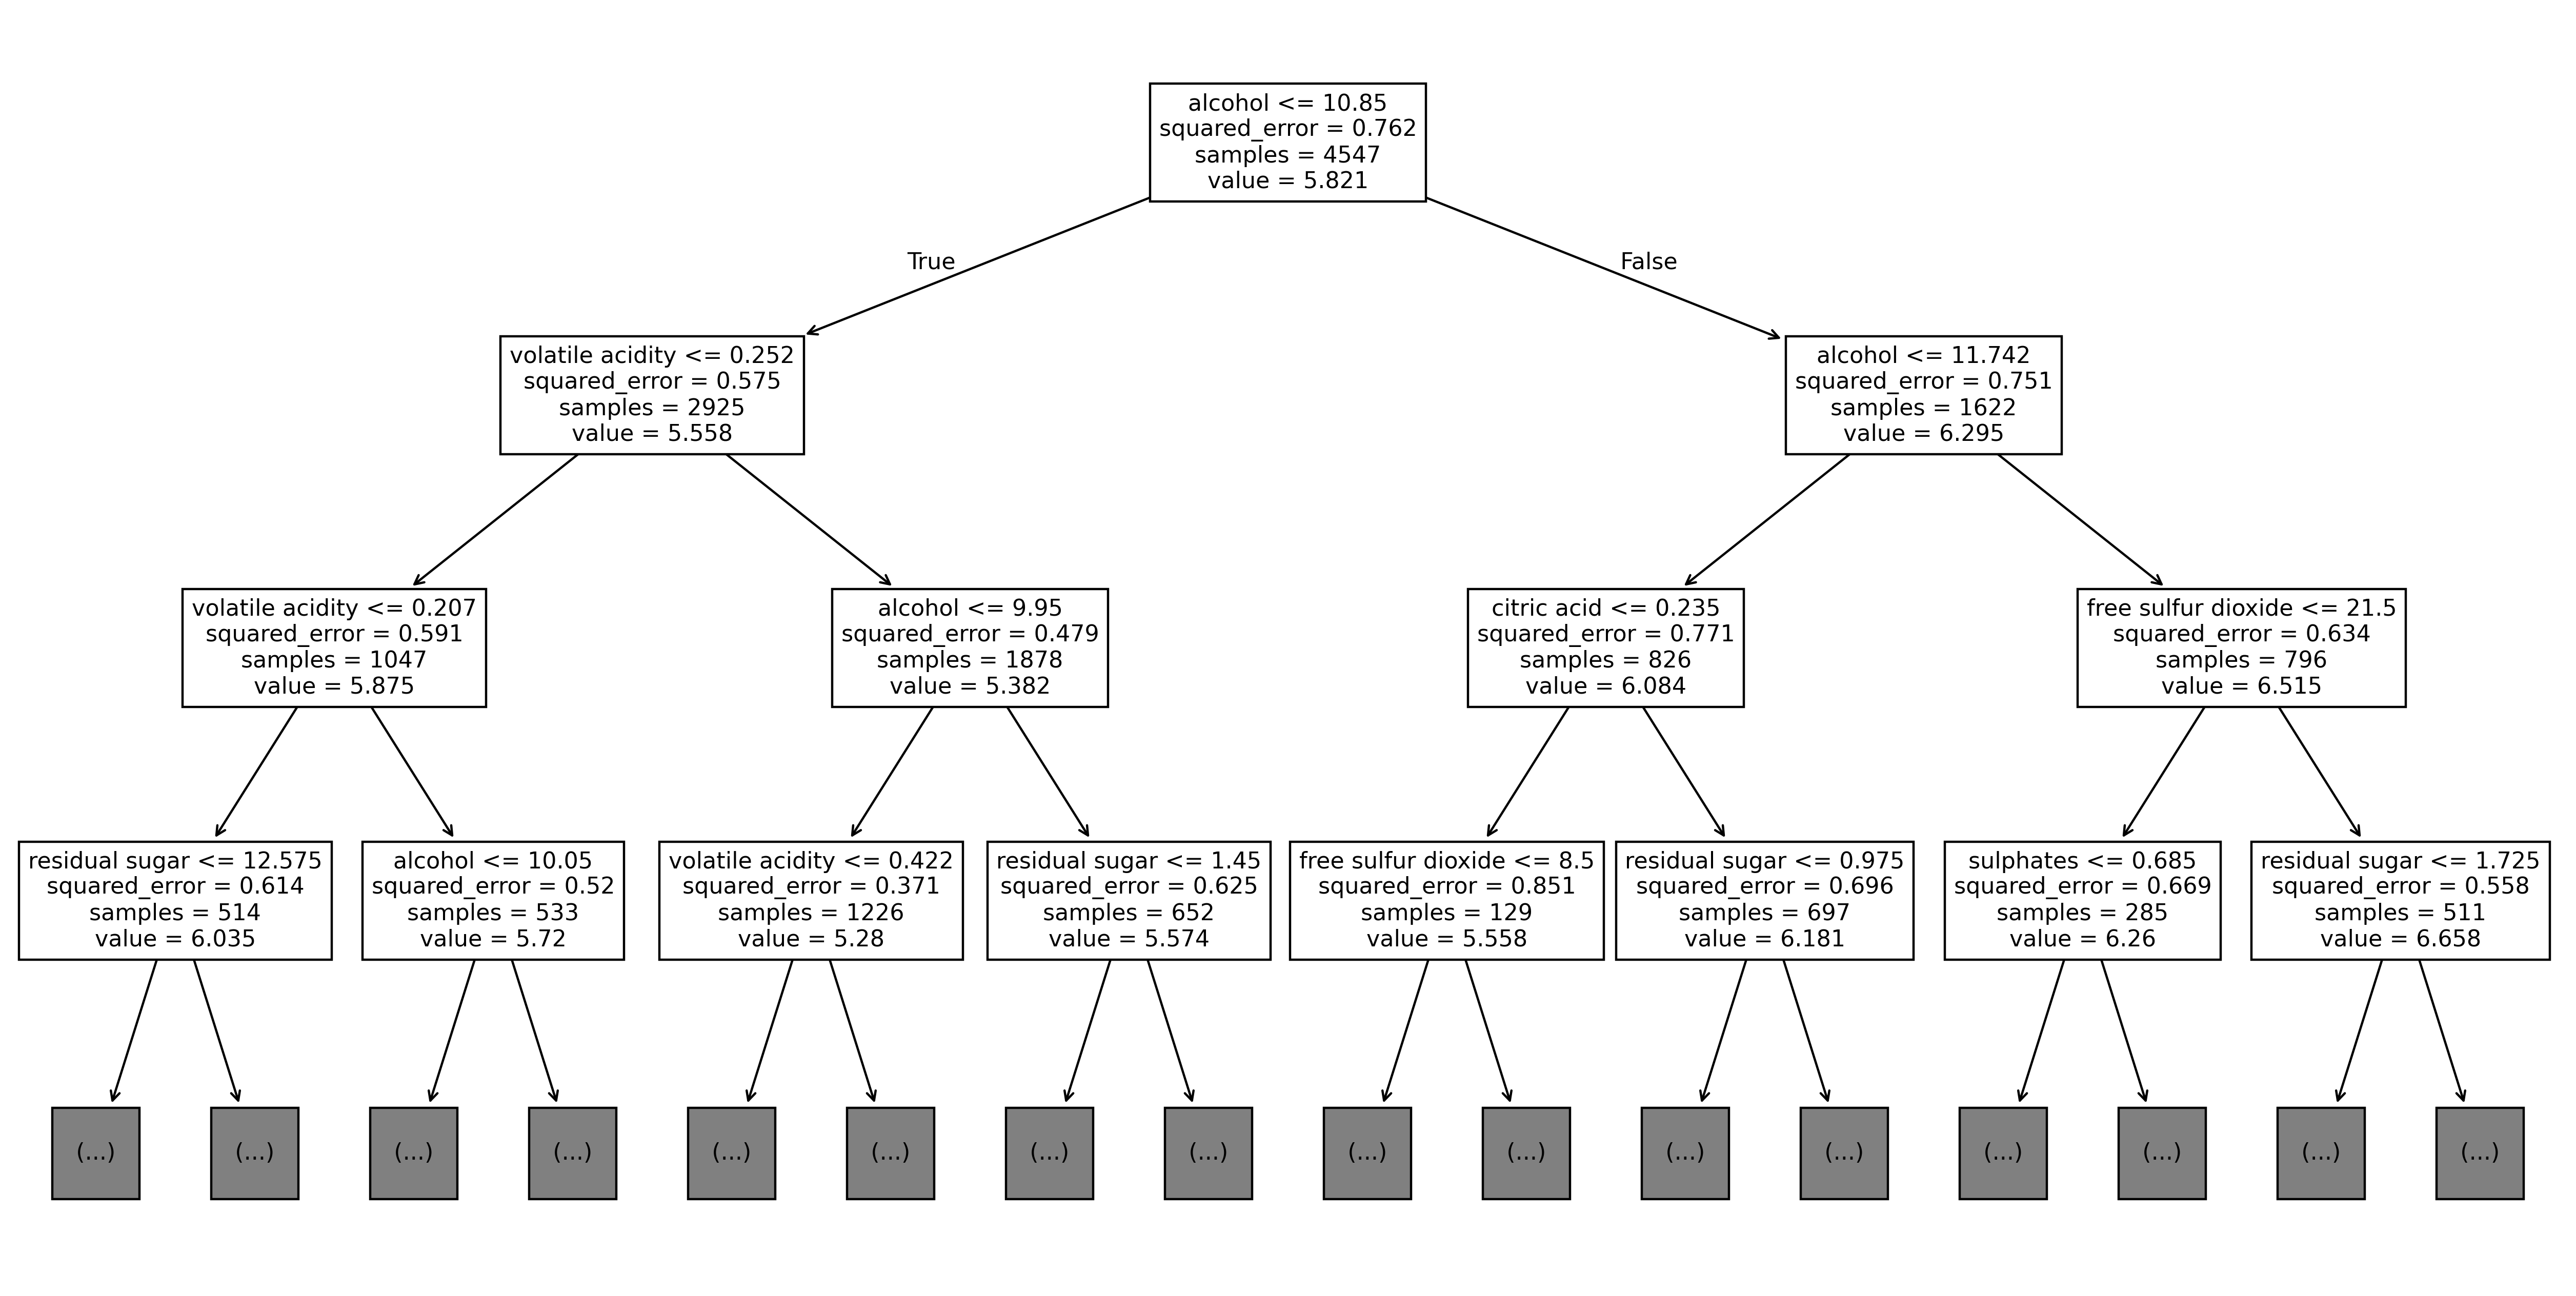

In [85]:
plt.figure(figsize = (20, 10), dpi = 320)

plot_tree(
    best_reg_tree_model,
    max_depth = 3,
    feature_names = X_reg.columns,
    fontsize = 10
)

plt.show()

**Модели ансамблей**